In [1]:
import torch
import torch.optim
import torch.nn as nn
from torch.utils.data import dataloader
from torchvision.transforms import  transforms
import torchvision.utils as vutils
import numpy as np
from timeit import default_timer as timer
from tqdm.auto import tqdm 
import matplotlib.pyplot as plt
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda) 

2.10.0+cpu
False
None


In [2]:
import os
from PIL import Image
from torch.utils.data import Dataset

class CelebA(Dataset):
  def __init__(self, root, transform=None):
    self.root = root
    # Filter for common image extensions to ensure only image files are loaded
    self.image_files = [f for f in os.listdir(root) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    self.transform = transform

  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, idx):
    img_path = os.path.join(self.root, self.image_files[idx])
    img = Image.open(img_path).convert('RGB')
    if self.transform:
      img = self.transform(img)
    return img

In [3]:
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [7]:
#variance schedule
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end , steps=T)
aplhas = 1. - betas 
alphas_cumprod = torch.cumprod(aplhas, dim=0)
alphas_cumprod = alphas_cumprod.to(device)

In [8]:
#Forward pass 
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_lile(x0)
        
    sqrt_alphas_cumprod = torch.sqrt(aplhas_cumprod[t]).view(-1,-1,1,1)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod[t]).view(-1,-1,1,1)
    
    return sqrt_alphas_cumprod*x0 + sqrt_one_minus_alphas_cumprod*noise

In [16]:
#SinusoidalPositionEmbeddings

import math 
import torch 

class Sinusoidal_Embeddings(torch.nn.Module):
    def __init__(self, dim:int):
        super().__init__()
        assert dim % 2 ==0 , 'Embeddings must be divisble by two to create to sin and cos waves'
        self.dim = dim
    def forward(self, time_stamps:torch.Tensor) -> torch.Tensor:
        device = time_stamps.device
        half_dim = self.dim // 2
        scale  = math.log(10000)/(half_dim - 1)
        freq = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=device) * -scale)
        embeddings = time_stamps[:, None].float() * freq[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings 

In [17]:
#Time embeddings 

class Time_embeddings(torch.nn.Module):
    def __init__(self, time_emb_dim: int, out_dim: int):
        super().__init__()
        self.sinusoidal_emb = SinusoidalPositionEmbeddings(time_emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(time_emb_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )
    def forward(self, time_steps:torch.Tensor)-> torch.Tensor:
        raw_emb = self.sinusoidal_emb(time_steps)
        return self.mlp(raw_emb)

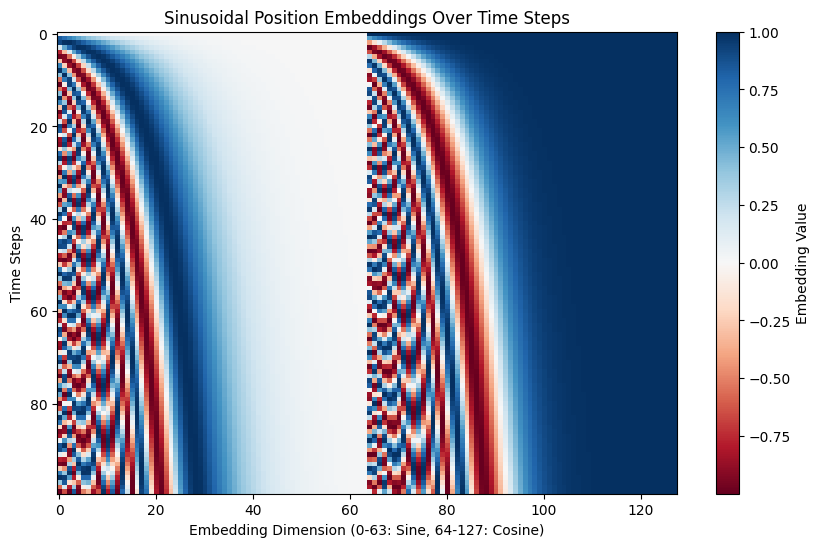

In [18]:
# 1. Instantiate the embedding layer with 128 dimensions
embedding_dim = 128
pos_embedding = Sinusoidal_Embeddings(dim=embedding_dim)

# 2. Create a batch of 100 chronological time steps (0 to 99)
time_stamps = torch.arange(100)

# 3. Generate the embeddings (Output shape will be)
embeddings = pos_embedding(time_stamps)

# 4. Plot the resulting matrix as a heatmap
plt.figure(figsize=(10, 6))
plt.imshow(embeddings.numpy(), cmap="RdBu", aspect="auto")
plt.colorbar(label="Embedding Value")
plt.title("Sinusoidal Position Embeddings Over Time Steps")
plt.xlabel("Embedding Dimension (0-63: Sine, 64-127: Cosine)")
plt.ylabel("Time Steps")
plt.show()


In [ ]:
# Resblock

class Resblock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 4, padding=1)
        self.conv2 - nn.Conv2d(out_channels, out_channels, 4, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.silu = nn.SiLU()
        self.time_mlp = nn.Linear(time_emd_dim, out_channels)
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) in_channels != out_channels else nn.Identity()

    def forward(self, x, time_mb):
        h = self.norm1(self.conv1(x))
        h = self.silu(h)
        time_proj = self.silu(self.time_mlp(time_emb))[:, :, None, None]    #(B, out_channels) → (B, out_channels, 1, 1)
        h = h + time_proj
        h = self.norm2(self.conv2(h))
        h = self.silu(h)
        return h + self.residual_conv(x)
        

In [ ]:
#downsample and up sample
class down_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)
    def forward(self, x):
        return self.conv(x)

class up_sample(torch.nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.transpose = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding1)
    def forward(self, x):
        return self.transpose(x)
        

In [2]:
#Self Attention block 
import torch.nn.functional as F

class Self_Attention(nn.Module):
    def __init__(self, channels, num_heads=8):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads

        self.norm = nn.GroupNorm(32, channels)
        self.to_qkv = nn.Linear(channels, channels*3)
        self.proj_out = nn.Linear(channels, channels)

    def forward(self, x):
        b, c, h, w = x.shape
        x_norm = self.norm(x)
        x_flat = x_norm.view(b, c, h*w).transpose(2,1) # [batch, channels, h*w] -> [batch, h*w, channels]
        
        #Matrices for Query ,Key and Value
        qkv = self.to_qkv(x_flat)
        q,k,v = qkv.chunk(3, dim=-1)

        #Matrices for mutli-head splitting
        #[batch, h*w, channles]->[batch, h*w, num_heads, head_dim]->[batch, num_heads, h*w, head_dim]
        q = q.view(b, -1, self.num_heads, self.head_dim).transpose(1,2)
        k = k.view(b, -1, self.num_heads, self.head_dim).transpose(1,2)
        v = v.view(b, -1, self.num_heads, self.head_dim).transpose(1,2)

        #Calculate dot product for attebtion scores
        attn_out = F.scaled_dot_product_attention(q, k, v)

        #Projecting image 
        out = attn_out.transpose(1,2).reshape(b, h*w, c)
        out = self.proj_out(out)
        out = out.transpose(1,2).reshape(b, c, h, w)
        return x+out 


In [ ]:
#Full Unet class 

class Unet(torch.nn.Module):
    def __init__(self, in_channels=3, time_emb_dim=128):
        super().__init__()
        #Time embedding dimemension
        self.time_emb = Time_embeddings(time_emb_dim, out_dim=256)

        #Encoder
        self.inc = nn.Conv2d(in_channels, 64, 3 ,padding=1)
        self.resblock1 = ResBlock(64, 64, time_emb_dim=256)
        self.resblock2 = ResBlock(64, 64, time_emb_dim=256)
        self.down1 = Down_sample(64)
        self.resblock3 = ResBlock(64, 128, time_emb_dim=256)
        self.resblock4 = ResBlock(128, 128, time_emb_dim=256)
        self.down2 = Down_sample(128)
        self.resblock5 = ResBlock(128, 256, time_emb_dim=256)
        self.resblock6 = ResBlock(256, 256, time_emb_dim=256)
        self.self_att1 = Self_Attention(256,8)
        self.down3 = Down_sample(256)
        self.resblock7= ResBlock(256, 512, time_emb_dim=256)
        self.resblock8= ResBlock(512, 512, time_emb_dim=256)

        #Bottelneck
        self.bott1 = ResBlock(512, 512, time_emb_dim=256)
        self.self_att2 = Self_Attention(512, 8)
        self.bott2 = ResBlock(512, 512, time_emb_dim=256)

        #Decoder
        self.resblock11 = ResBlock(1024, 512, time_emb_dim=256)
        self.resblock12 = ResBlock(1024, 512, time_emb_dim=256)
        self.up1 = Up_sample(512)
        self.resblock13 = ResBlock(768, 256, time_emb_dim=256)   
        self.resblock14 = ResBlock(512, 256, time_emb_dim=256)
        self.self_att3 = Self_Attention(256, 8)
        self.up2 = Up_sample(256)
        self.resblock15 = ResBlock(384, 128, time_emb_dim=256)
        self.resblock16 = ResBlock(256, 128, time_emb_dim=256)
        self.up3 = Up_sample(128)
        self.resblock17 = ResBlock(192, 64, time_emb_dim=256)
        self.resblock18 = ResBlock(128, 64, time_emb_dim=256)
        self.outc = nn.Conv2d(64, in_channels, 3, padding=1)

    def forward(self, x ,t):
      t_emb = self.time_emb(t)

      #Encoder
      x1 = self.inc(x)
      x2 = self.resblock1(x1, t_emb)
      x3 = self.resblock2(x2, t_emb)
      x4 = self.down1(x3)
      x5 = self.resblock3(x4, t_emb)
      x6 = self.resblock4(x5, t_emb)
      x7 = self.down2(x6)
      x8 = self.resblock5(x7, t_emb)
      x9 = self.resblock6(x8, t_emb)
      x10 = self.self_att1(x9)
      x11 = self.down3(x10)
      x12 = self.resblock7(x11, t_emb)
      x13 = self.resblock8(x12, t_emb)

      #Bottleneck
      x14 = self.bott1(x13, t_emb)
      x15 = self.self_att2(x14)
      x16 = self.bott2(x15, t_emb)

      #Decoder
      x17 = torch.cat([x16, x13], dim=1)
      x18 = self.resblock11(x17, t_emb)
      x19 = torch.cat([x18, x12], dim=1)
      x20 = self.resblock12(x19, t_emb)
      x21 = self.up1(x20)
      x22 = torch.cat([x21, x9], dim=1)
      x23 = self.resblock13(x22, t_emb)
      x24 = torch.cat([x23, x8], dim=1)
      x25 = self.resblock14(x24, t_emb) 
      x26 = self.self_att3(x25)
      x27 = self.up2(x26)
      x28 = torch.cat([x27, x6],dim=1)
      x29 = self.resblock15(x28, t_emb)
      x30 = torch.cat([x29, x5],dim=1)
      x31 = self.resblock16(x30, t_emb)
      x32 = self.up3(x31)
      x33 = torch.cat([x32, x3],dim=1)
      x34 = self.resblock17(x33,t_emb)
      x35 = torch.cat([x34, x2],dim=1)
      x36 = self.resblock18(x35, t_emb)
      return self.outc(x36)


In [1]:
#DDP setup process
import torch.distributed as dist
import torch.multiprocessing as mp 

def setup(rank , world_size):
    dist.init_process_group(
        backend='nccl',
        rank=rank,
        world_size=world_size
    )
    torch.cuda.set_device(rank)

def cleanup():
    dist.destory_process_group()

In [ ]:
#EMA class 

class EMA():
    def __init__(self, model, decay=0.9999):
        self.model = model 
        self.decay = decay 
        self.backup = {}
        self.shadow = {}

    def register(self):
        for name , param in self.model.named_parameters():
            if param.requires_grad :
                self.shadow[name] = param.data.clone()

    def update_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                assert name in self.shadow
                new_avg = self.decay*self.shadow +(1. - self.decay)*param.data
                self.shadow[name] = new_avg.clone()

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                assert name in self.shadow
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

  def restore(self):
      for name , param in self.model.named_parameters():
          if param.requires_grad:
              assert name in self.backup
              param.data.copy_(self.backup[name])
       self.backup = {}

In [ ]:
#Training
import torch.utils.data.Distributed as DistributedSampler
from torch.nn.Parallel import DistributedDataParallel as DDP 

epochs = 1

def train(rank, world_size):
    setup(rank, world_size)
    
    #Dataloader 
    dataroot = '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba'
    dataset = CelebA(root=dataroot, transform=data_transform)
    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    dataloader= DataLoader(dataset, batch_size=32, shuffle=False, sampler=sampler, num_workers=2, drop_last=True)
    
    #Building model 
    model = Unet().to(rank)
    model = DDP(model, device_ids=[rank])
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss = nn.MSELoss()

    for epoch in range(epochs):
        sampler.set_epoch(epoch)